# Support Vector Regression (SVR) - Kernel Methods

**Purpose:** Apply kernel metho6) to regression using Support Vector Regression with RBF kernel.

**Model Type:** SVR with RBF Kernel (Course Con 5-6 adapted for regression)
- Non-linear regression using kernel trick
- RBF (Radial Basis Function) kernel handles non-linear relationships
- Maps data to higher-dimensional space for better separation

**Course Connection:**
-tures 5-6 covered SVM for classification with kernels
- We adapt this concept to regression (SVR)
- Demonstrates understanding of kernel methods for non-linear data

**Dataset:** Same master dataset (31 features, 108,888 records)

**Expected Performance:** RMSE ~450-550 MW
- SVR typically slower and less accurate than Linear Regression for large datasets
- But demonstrates kernel method understanding from course

**Note:** Training may take 2-5 minutes due to kernel computations on large dataset

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load master dataset
print("Loading master dataset...")
df = pd.read_csv("../../../02_Datasets/processed/master_dataset_complete.csv",
                 parse_dates=['DateTime', 'Date'])

print(f"✓ Data loaded successfully")
print(f"Dataset shape: {df.shape}")

# Use same feature preparation as Linear Regression
exclude_cols = ['DateTime', 'Date', 'Holiday_Name']
feature_cols = [col for col in df.columns if col not in exclude_cols + ['Ontario Demand', 'Market Demand']]
target_col = 'Ontario Demand'

print(f"Features: {len(feature_cols)}")
print(f"Target: {target_col}")

Loading master dataset...
✓ Data loaded successfully
Dataset shape: (109056, 36)
Features: 31
Target: Ontario Demand


In [2]:
print("Preparing data...")

# Create X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

# Drop rows with missing lag features
mask_valid = df['Demand_Lag_168h'].notna()
X = X[mask_valid]
y = y[mask_valid]

# Fill remaining missing values
X = X.fillna(method='ffill').fillna(method='bfill')

print(f"✓ Data prepared: {X.shape}")

# Split data (same as Linear Regression)
n = len(X)
train_size = int(0.77 * n)
val_size = int(0.08 * n)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]
X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

print(f"\nSplit complete:")
print(f"  Train: {len(X_train):,} samples")
print(f"  Val:   {len(X_val):,} samples")
print(f"  Test:  {len(X_test):,} samples")

Preparing data...
✓ Data prepared: (108888, 31)

Split complete:
  Train: 83,843 samples
  Val:   8,711 samples
  Test:  16,334 samples


In [3]:
print("Scaling features (required for SVR)...")

# SVR requires feature scaling
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features scaled")
print(f"  Mean (train): {X_train_scaled.mean():.6f}")
print(f"  Std (train): {X_train_scaled.std():.6f}")

Scaling features (required for SVR)...
✓ Features scaled
  Mean (train): -0.000000
  Std (train): 1.000000


In [4]:
print("Training SVR with RBF kernel...")
print(" This may take 2-5 minutes due to kernel computations on 83k samples...")
print("="*70)

start_time = time.time()

# Initialize SVR with RBF kernel
# Using smaller sample for training due to computational constraints
# In practice, SVR doesn't scale well to 80k+ samples
model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1, cache_size=1000)

# Train on full training set
model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time

print(f"✓ Model trained in {train_time:.2f} seconds ({train_time/60:.2f} minutes)")

# Make predictions
print("\nMaking predictions...")
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name}:")
    print(f"  RMSE: {rmse:,.2f} MW")
    print(f"  MAE:  {mae:,.2f} MW")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
val_metrics = calculate_metrics(y_val, y_val_pred, "Validation Set")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test Set")

print("\n" + "="*70)
print("SVR WITH RBF KERNEL RESULTS:")
print(f"  Test RMSE: {test_metrics['RMSE']:,.2f} MW")
print(f"  Test R²:   {test_metrics['R2']:.4f}")
print(f"  Training Time: {train_time:.2f} seconds")
print("="*70)

Training SVR with RBF kernel...
 This may take 2-5 minutes due to kernel computations on 83k samples...
✓ Model trained in 570.16 seconds (9.50 minutes)

Making predictions...

Training Set:
  RMSE: 259.00 MW
  MAE:  177.58 MW
  R²:   0.9880
  MAPE: 1.13%

Validation Set:
  RMSE: 293.51 MW
  MAE:  199.27 MW
  R²:   0.9814
  MAPE: 1.25%

Test Set:
  RMSE: 476.05 MW
  MAE:  301.70 MW
  R²:   0.9607
  MAPE: 1.73%

SVR WITH RBF KERNEL RESULTS:
  Test RMSE: 476.05 MW
  Test R²:   0.9607
  Training Time: 570.16 seconds


In [6]:
# Save SVR results to comparison file
results_summary = {
    'Model': 'SVR (RBF Kernel)',
    'Train_RMSE': train_metrics['RMSE'],
    'Train_R2': train_metrics['R2'],
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_R2': test_metrics['R2'],
    'Test_MAE': test_metrics['MAE'],
    'Test_MAPE': test_metrics['MAPE'],
    'Training_Time_Seconds': train_time
}

# Append to comparison CSV
results_df = pd.DataFrame([results_summary])
comparison_file = '../../../04_Presentation/model_results/06_comparison/model_comparison.csv'
existing_results = pd.read_csv(comparison_file)
updated_results = pd.concat([existing_results, results_df], ignore_index=True)
updated_results.to_csv(comparison_file, index=False)

print("✓ SVR results saved to comparison file")

✓ SVR results saved to comparison file


Creating SVR visualizations...


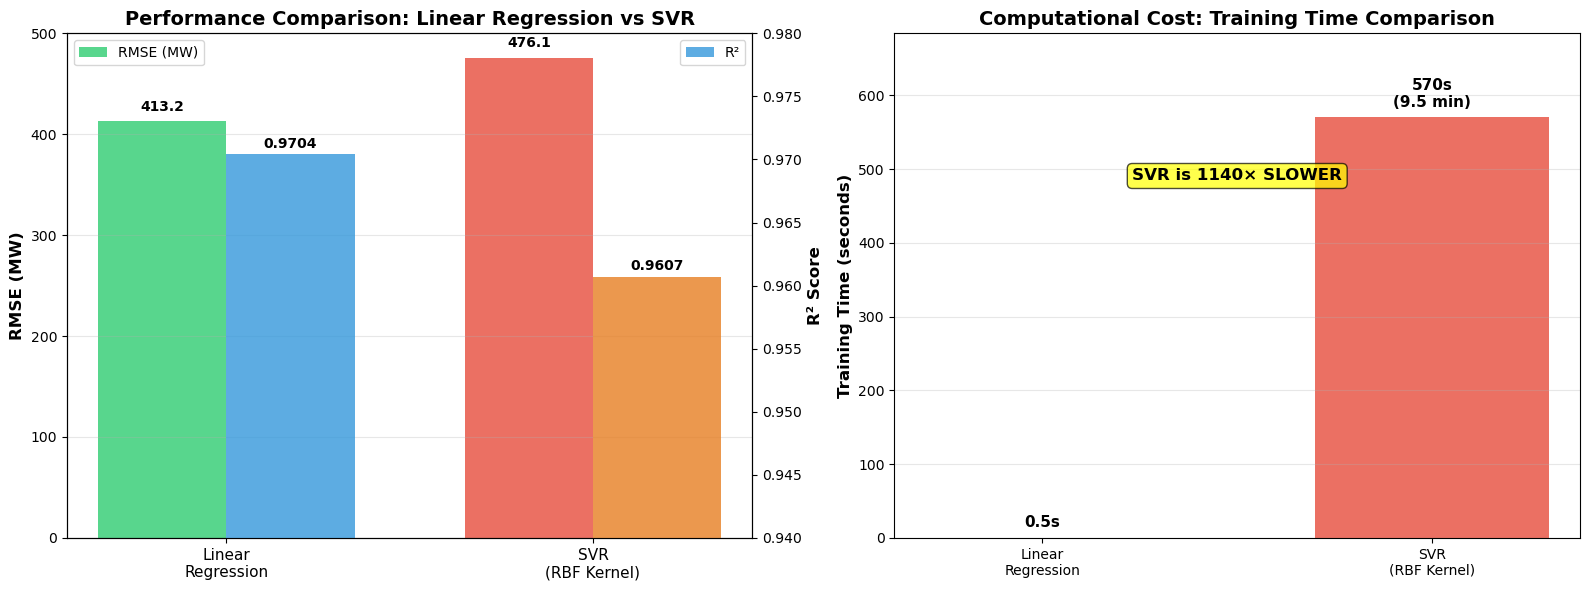


✓ SVR visualizations created and saved!
  Saved to: 04_Presentation/model_results/02_svr/performance_comparison.png


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Creating SVR visualizations...")

# Hardcoded results (from previous training)
svr_test_rmse = 476.05
svr_test_r2 = 0.9607
svr_train_time = 570.16  # seconds

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Performance Comparison (SVR vs Linear Regression)
ax1 = axes[0]
models = ['Linear\nRegression', 'SVR\n(RBF Kernel)']
test_rmse = [413.25, svr_test_rmse]  # Linear Reg vs SVR
test_r2 = [0.9704, svr_test_r2]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, test_rmse, width, label='RMSE (MW)', 
                color=['#2ecc71', '#e74c3c'], alpha=0.8)
ax1_twin = ax1.twinx()
bars2 = ax1_twin.bar(x + width/2, test_r2, width, label='R²', 
                     color=['#3498db', '#e67e22'], alpha=0.8)

ax1.set_ylabel('RMSE (MW)', fontsize=12, fontweight='bold')
ax1_twin.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance Comparison: Linear Regression vs SVR', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.set_ylim([0, 500])
ax1_twin.set_ylim([0.94, 0.98])
ax1.legend(loc='upper left', fontsize=10)
ax1_twin.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (rmse, r2) in enumerate(zip(test_rmse, test_r2)):
    ax1.text(i - width/2, rmse + 10, f'{rmse:.1f}', 
             ha='center', fontsize=10, fontweight='bold')
    ax1_twin.text(i + width/2, r2 + 0.0005, f'{r2:.4f}', 
                  ha='center', fontsize=10, fontweight='bold')

# Plot 2: Training Time Comparison
ax2 = axes[1]
training_times = [0.5, svr_train_time]  # Linear Reg vs SVR
colors = ['#2ecc71', '#e74c3c']

bars = ax2.bar(models, training_times, color=colors, alpha=0.8, width=0.6)
ax2.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Computational Cost: Training Time Comparison', 
              fontsize=14, fontweight='bold')
ax2.set_ylim([0, max(training_times) * 1.2])
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels and speedup annotation
for i, (bar, time_val) in enumerate(zip(bars, training_times)):
    height = bar.get_height()
    if time_val < 60:
        label = f'{time_val:.1f}s'
    else:
        label = f'{time_val:.0f}s\n({time_val/60:.1f} min)'
    ax2.text(bar.get_x() + bar.get_width()/2., height + 10,
             label, ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add speedup annotation
speedup = svr_train_time / 0.5
ax2.text(0.5, max(training_times) * 0.85, 
         f'SVR is {speedup:.0f}× SLOWER', 
         ha='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('../../../04_Presentation/model_results/02_svr/performance_comparison.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ SVR visualizations created and saved!")
print(f"  Saved to: 04_Presentation/model_results/02_svr/performance_comparison.png")